# Signal Processing

This tutorial gives an in depth overview of the ``PhotometryExperiment`` class. ``PhotometryExperiment`` represents one continuous photometry recording and provides tools for preprocessing traces, inspecting reference fits, trimming recordings, exporting continuous data, and extracting trial-wise ``PhotometryData``.

The most important idea is that ``PhotometryExperiment`` works with continuous data, while ``PhotometryData`` works with trial-wise data.

A typical workflow is:

1. Load a continuous experiment.

2. Inspect raw traces and event labels.

3. Preprocess the continuous signal.

4. Extract trial windows around behavioral events.

5. Analyze or save the resulting ``PhotometryData`` object.

# Setup

First we import the packages used throughout the tutorial.

In [1]:
import numpy as np
import pandas as pd
from plotnine import * # type: ignore

from PhoPro import PhotometryExperiment, PhotometryData

The examples below use the bundled CSV experiment. To keep each section independent, we will define helper functions that reload a fresh experiment whenever needed.

In [2]:
EVENT_COLS = ['trial_cue', 'lever1', 'lever2', 'shock']


def load_example(isosbestic: bool = True) -> PhotometryExperiment:
    return PhotometryExperiment.load_CSV(
        csv='data/experiments/example_experiment.csv',
        time_col='time',
        signal_col='raw_signal',
        isosbestic_col='raw_isosbestic' if isosbestic else None,
        event_cols=EVENT_COLS,
        annotation_file='data/experiments/example_annotation.json',
        annotation_handler='json',
    )


def load_processed(**preprocess_kwargs) -> PhotometryExperiment:
    exp = load_example()
    exp.id = 'Processed example'
    kwargs = dict(
        cutoff_frequency=3,
        order=4,
        correction_method='dF/F',
        fit_using='IRLS',
        maxiter=2000,
        c=2,
    )
    kwargs.update(preprocess_kwargs)
    exp.preprocess_signal(**kwargs)
    return exp

# 1. Loading a Continuous Experiment

``PhotometryExperiment`` can be created directly from arrays, but most workflows use a loader. The convenience class methods ``load_CSV`` and ``load_TDT`` create the appropriate loader and return a ``PhotometryExperiment``.

In [3]:
exp = load_example()
exp.id = 'Dual-channel example'

exp

Dual channel photometry experiment with 100000 timepoints.

A dual-channel experiment contains both the experimental signal and an isosbestic reference. A single-channel experiment has only the experimental signal.

In [4]:
print(exp.channel_mode)
print(exp.has_isosbestic)
print(exp.n_times)
print(exp.frequency)

dual
True
100000
99.90109791306607


The continuous arrays are stored on the object. ``time`` aligns with ``raw_signal`` and, when present, ``raw_isosbestic``.

In [5]:
print(exp.time[:5])
print(exp.raw_signal[:5])
print(exp.raw_isosbestic[:5]) #type: ignore

[0.   0.01 0.02 0.03 0.04]
[59.44461267 59.6544524  58.9162265  59.30105963 59.53502938]
[47.69133434 47.53493632 47.07341753 47.31350147 46.4017177 ]


Events are stored in a dictionary mapping event labels to timestamp arrays.

In [6]:
print(exp.event_labels)
{k: len(v) for k, v in exp.events.items()}

['trial_cue', 'lever1', 'lever2', 'shock']


{'trial_cue': 20, 'lever1': 9, 'lever2': 6, 'shock': 3}

Metadata from annotation files is stored in ``metadata``. Built-in loaders also include the source file path.

In [7]:
exp.metadata

{'source': 'data/experiments/example_experiment.csv',
 'subject': 'animal_1',
 'sex': 'male',
 'age': 'young'}

# 2. Inspecting Raw Data

``plot_dashboard`` gives a quick view of the continuous recording. Before preprocessing, ``raw='auto'`` shows the raw signal and raw isosbestic traces.

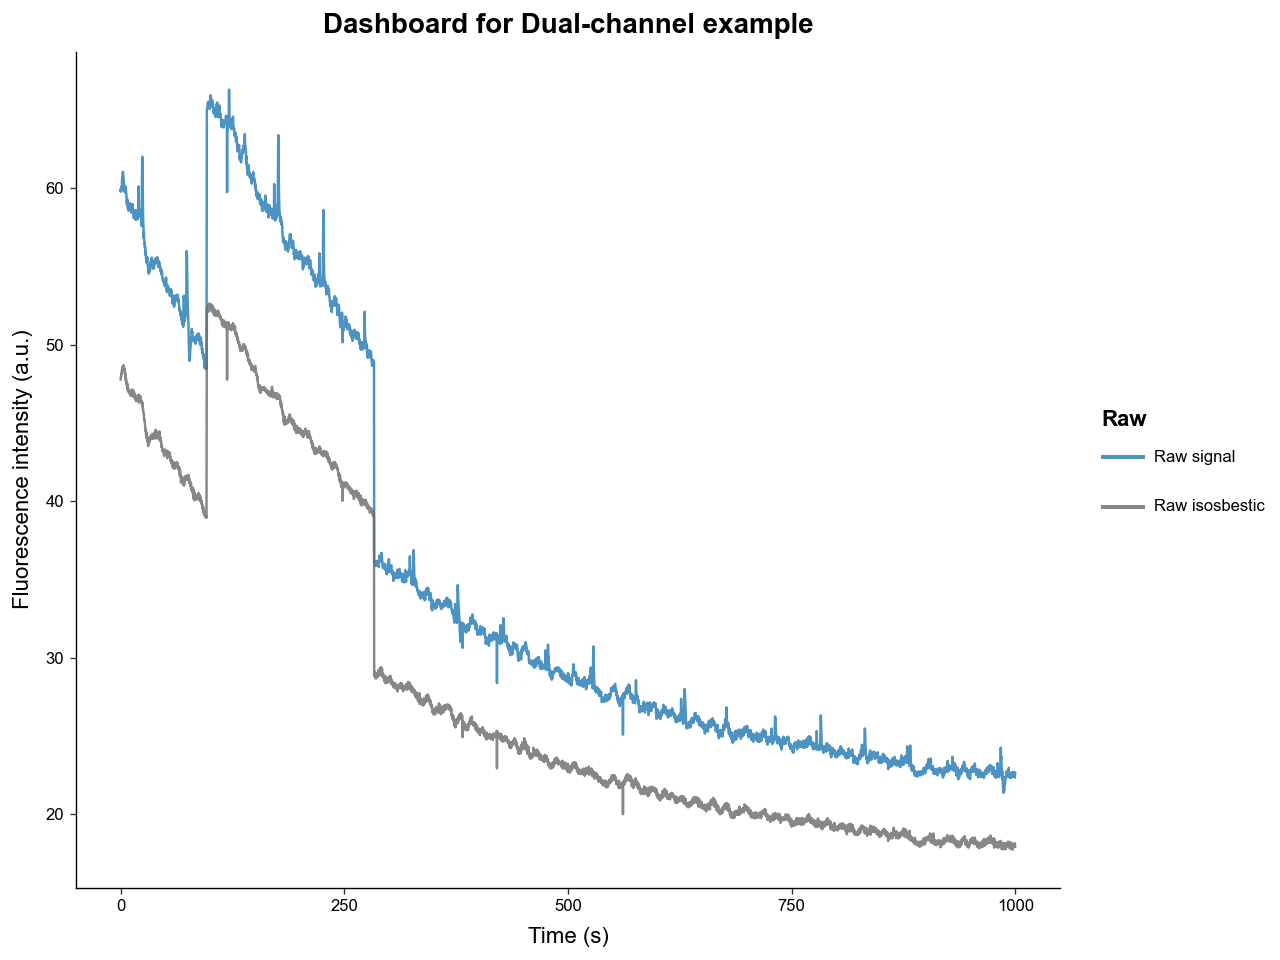

In [8]:
exp.plot_dashboard(downsample=20)

The plotting methods return plotnine objects, so they can be modified before display.

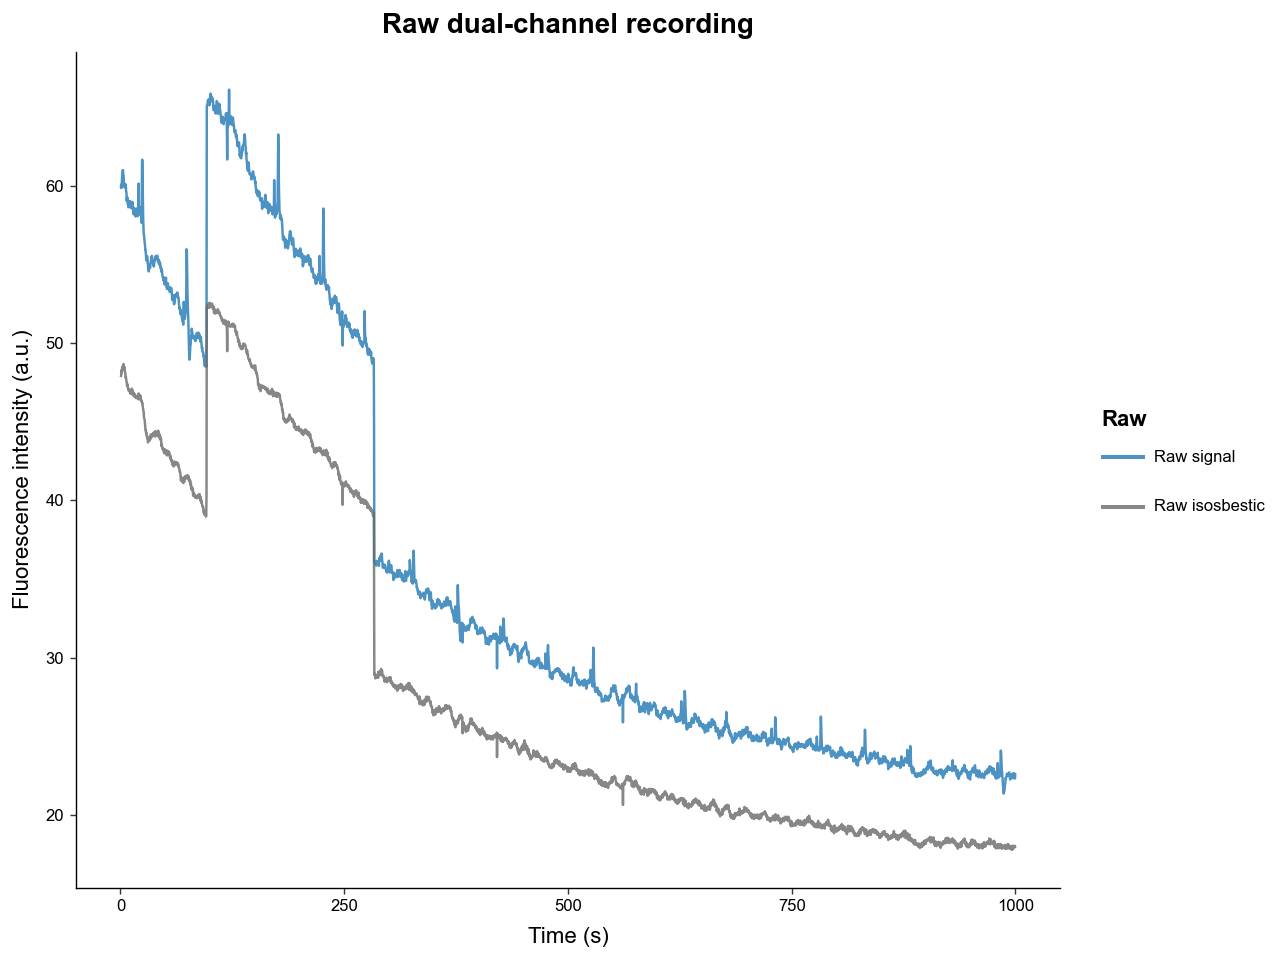

In [ ]:
p: ggplot = exp.plot_dashboard(downsample=30)

p + labs(title='Raw dual-channel recording')

Continuous data can also be inspected as a dataframe. ``to_wide_dataframe`` keeps one row per timepoint.

In [10]:
raw_wide = exp.to_wide_dataframe(
    downsample=100,
    export_events=True,
)

raw_wide.head()

,time,raw_signal,raw_isosbestic,trial_cue,lever1,lever2,shock
0,0.495,59.903096,47.916538,False,False,False,False
1,1.495,60.238973,48.241356,False,False,False,False
2,2.495,60.902518,48.491188,False,False,False,False
3,3.495,60.526398,48.509135,False,False,False,False
4,4.495,59.875875,48.366708,False,False,False,False


``to_long_dataframe`` keeps one row per timepoint and trace source. This is the format used by the dashboard plotting helper.

In [11]:
raw_long = exp.to_long_dataframe(downsample=100)
raw_long.head()

,time,source,value
0,0.495,raw_signal,59.903096
1,1.495,raw_signal,60.238973
2,2.495,raw_signal,60.902518
3,3.495,raw_signal,60.526398
4,4.495,raw_signal,59.875875


# 3. Low-pass Filtering and Reference Fitting

``preprocess_signal`` combines the main preprocessing steps, but the lower-level helpers are also available. The first step is usually a low-pass Butterworth filter.

In [12]:
filtered_signal = exp.low_frequency_pass_butter(
    signal=exp.raw_signal,
    sample_frequency=exp.frequency,
    cutoff_frequency=3,
    order=4,
)

filtered_isosbestic = exp.low_frequency_pass_butter(
    signal=exp.raw_isosbestic,
    sample_frequency=exp.frequency,
    cutoff_frequency=3,
    order=4,
)

filtered_signal[:5]

array([59.40280199, 59.4454649 , 59.48948715, 59.5341687 , 59.57882935])

In dual-channel experiments, the isosbestic trace is fitted to the experimental signal before correction. The package supports ordinary least squares and iteratively reweighted least squares, with or without an intercept.

In [13]:
fitted_ref, r2_val, coeffs = exp.fit_isosbestic_to_signal(
    signal=filtered_signal,
    isosbestic=filtered_isosbestic,
    fit_using='IRLS',
    maxiter=2000,
    c=2,
)

print(r2_val)
print(coeffs)

0.9990783751778679
[-0.01397495  1.25023965]


The fitted reference is the trace that will be subtracted or divided away during preprocessing.

In [14]:
pd.DataFrame({
    'time': exp.time[:5],
    'filtered_signal': filtered_signal[:5],
    'filtered_isosbestic': filtered_isosbestic[:5],
    'fitted_reference': fitted_ref[:5],
})

,time,filtered_signal,filtered_isosbestic,fitted_reference
0,0.00,59.402802,47.613779,59.514660
1,0.01,59.445465,47.616049,59.517498
2,0.02,59.489487,47.621917,59.524834
3,0.03,59.534169,47.631192,59.536430
4,0.04,59.578829,47.643640,59.551994


# 4. Dual-channel Preprocessing

``preprocess_signal`` runs filtering, reference fitting, correction, optional whole-signal normalization, and optional artifact correction. For many dual-channel experiments, a 3 Hz low-pass filter, IRLS reference fitting, and ``dF/F`` correction are a reasonable starting point.

In [15]:
exp = load_processed()

print(exp.has_ran_preprocess)
print(exp.signal.shape)
print(exp.fitted_ref.shape)

True
(100000,)
(100000,)


After preprocessing, several attributes are populated:

* ``filt_sig``: filtered experimental signal.

* ``filt_iso``: filtered isosbestic signal for dual-channel data.

* ``fitted_ref``: fitted reference trace.

* ``signal``: final processed signal.

* ``metadata['reference_fit']``: fit type, fit quality, and coefficients.

* ``metadata['correction_method']``: the correction method used.

In [16]:
exp.metadata['reference_fit']

{'type': 'isosbestic',
 'r2_val': 0.9990783751778679,
 'coeffs': array([-0.01397495,  1.25023965])}

In [17]:
exp.metadata['correction_method']

'dF/F'

After preprocessing, ``plot_dashboard(raw=False)`` shows the filtered signal, fitted reference, and processed trace.

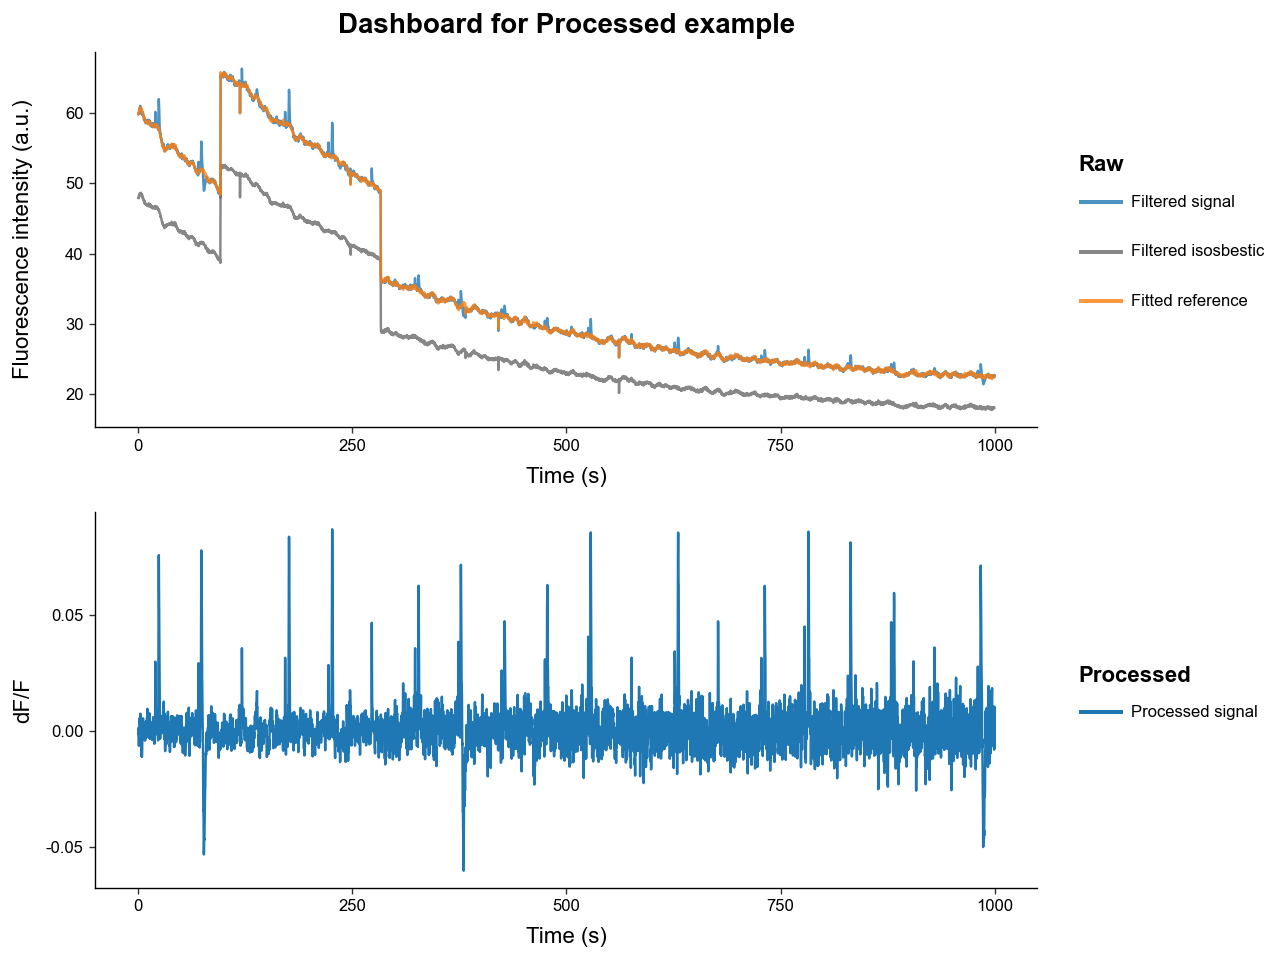

In [18]:
exp.plot_dashboard(raw=False, downsample=20)

The correction method can be changed. ``dF/F`` returns ``(signal - fitted_reference) / fitted_reference``. ``dF`` returns ``signal - fitted_reference``.

In [19]:
df_exp = load_processed(correction_method='dF')

print(df_exp.metadata['correction_method'])
print(df_exp.signal[:5])

dF
[-0.11185789 -0.07203312 -0.03534653 -0.00226166  0.02683503]


Whole-signal normalization can be applied after correction. Built-in options are ``'none'``, ``'zscore'``, and ``'nullZ'``.

In [20]:
z_exp = load_processed(signal_normalization='zscore')

print(np.mean(z_exp.signal))
print(np.std(z_exp.signal))

1.3073986337985844e-17
1.0


Custom correction and normalization functions can be passed directly. A custom correction function receives ``signal`` and ``fitted_ref`` and must return a one-dimensional processed signal.

In [21]:
def percent_dF_F(signal: np.ndarray, fitted_ref: np.ndarray) -> np.ndarray:
    return 100 * (signal - fitted_ref) / np.maximum(fitted_ref, np.finfo(np.float32).eps)

custom_exp = load_processed(correction_method=percent_dF_F)

print(custom_exp.metadata['correction_method'])
print(custom_exp.signal[:5])

percent_dF_F
[-0.18795015 -0.12102847 -0.05938115 -0.00379879  0.04506151]


# 5. Single-channel Preprocessing

Single-channel experiments do not have an isosbestic reference. In that case, ``preprocess_signal`` fits a photobleaching curve and uses single-channel correction methods such as ``dB/B`` or ``dB``.

In [22]:
single = load_example(isosbestic=False)

print(single.channel_mode)
print(single.has_isosbestic)

single
False


In [23]:
single.preprocess_signal(
    cutoff_frequency=3,
    order=4,
    correction_method='dB/B',
    signal_normalization='none',
    channel_mode='single',
)

print(single.metadata['reference_fit']['type'])
print(single.metadata['reference_fit']['r2_val'])

photobleaching
0.802771824760193


The photobleaching curve can also be fit directly with ``fit_photobleaching_curve``.

In [24]:
bleach_curve, bleach_r2, bleach_params = single.fit_photobleaching_curve(
    signal=single.filt_sig,
)

print(bleach_r2)
print(bleach_params)

0.802771824760193
[2.00570529e-09 5.00005000e-03 4.00536551e+01 3.10490378e-03
 2.05369340e+01]


# 6. Optional Artifact Detection and Correction

``preprocess_signal`` accepts an ``artifact_detector`` and ``artifact_corrector``. Detectors identify artifact intervals and correctors replace or adjust the processed signal in those intervals.

Artifact settings are experiment-specific, so the safest pattern is to inspect the raw and processed traces, tune the detector on representative recordings, then apply the chosen detector and corrector consistently.

In [25]:
from PhoPro.analysis.artifact import ODS_Detector, Spline_Corrector

# Example configuration. Tune thresholds for your own data before using it in production.
detector = ODS_Detector(
    score_threshold=8,
    jump_score_threshold=8,
    expand_sec=(0.5, 2),
    buffer_sec=1.5,
    n_chunks=50,
)

corrector = Spline_Corrector(
    anchor_sec=(0.2, 0.2),
    correct_spikes=True,
    correct_jumps=True,
)

print(detector)
print(corrector)

To run artifact correction, pass the detector and corrector to ``preprocess_signal``. This cell is commented out so the tutorial does not imply that one detector configuration is universally appropriate.

In [26]:
# artifact_exp = load_example()
# artifact_exp.preprocess_signal(
#     cutoff_frequency=3,
#     order=4,
#     correction_method='dF/F',
#     fit_using='IRLS',
#     artifact_detector=detector,
#     artifact_corrector=corrector,
# )
# artifact_exp.artifacts.df.head()

# 7. Trimming Continuous Recordings

``trim_times_by_index`` and ``trim_times_by_values`` remove timepoints from the continuous recording. They also trim every present trace and remove event timestamps outside the new time range.

It is best to trim before trial extraction or artifact correction so all derived results stay aligned.

In [27]:
trimmed = load_example()
trimmed.trim_times_by_values(lower=100, upper=200)

print(trimmed.time[0], trimmed.time[-1])
print(trimmed.n_times)
print({k: len(v) for k, v in trimmed.events.items()})

100.0 200.0
10001
{'trial_cue': 2, 'lever1': 1, 'lever2': 0, 'shock': 0}


Index trimming uses an inclusive ``start_idx`` and an exclusive ``stop_idx``.

In [28]:
trimmed_by_index = load_example()
trimmed_by_index.trim_times_by_index(start_idx=1000, stop_idx=2000)

print(trimmed_by_index.time[0], trimmed_by_index.time[-1])
print(trimmed_by_index.raw_signal.shape)

10.0 19.99
(1000,)


# 8. Exporting Continuous Data

Continuous experiment traces can be exported as wide or long dataframes. The export methods include whatever traces are available at the time they are called.

In [29]:
processed_wide = exp.to_wide_dataframe(
    downsample=100,
    export_events=True,
)

processed_wide.head()

,time,raw_signal,raw_isosbestic,processed_signal,fitted_reference,filtered_signal,filtered_isosbestic,trial_cue,lever1,lever2,shock
0,0.495,59.903096,47.916538,-0.000114,59.902275,59.895029,47.923811,False,False,False,False
1,1.495,60.238973,48.241356,-0.000829,60.299507,60.249491,48.241534,False,False,False,False
2,2.495,60.902518,48.491188,0.004537,60.619919,60.894823,48.497814,False,False,False,False
3,3.495,60.526398,48.509135,-0.001432,60.621269,60.534485,48.498897,False,False,False,False
4,4.495,59.875875,48.366708,-0.009521,60.457298,59.881420,48.367745,False,False,False,False


In [30]:
processed_long = exp.to_long_dataframe(downsample=100)
processed_long.head()

,time,source,value
0,0.495,raw_signal,59.903096
1,1.495,raw_signal,60.238973
2,2.495,raw_signal,60.902518
3,3.495,raw_signal,60.526398
4,4.495,raw_signal,59.875875


Use ``write_csv`` when you want to save the continuous traces to disk.

In [31]:
exp.write_csv(
    file='output/processed_experiment_wide.csv',
    downsample=100,
    export_events=True,
    format='wide',
)

pd.read_csv('output/processed_experiment_wide.csv').head()

,Unnamed: 0,time,raw_signal,raw_isosbestic,processed_signal,fitted_reference,filtered_signal,filtered_isosbestic,trial_cue,lever1,lever2,shock
0,0,0.495,59.903096,47.916538,-0.000114,59.902275,59.895029,47.923811,False,False,False,False
1,1,1.495,60.238973,48.241356,-0.000829,60.299507,60.249491,48.241534,False,False,False,False
2,2,2.495,60.902518,48.491188,0.004537,60.619920,60.894823,48.497814,False,False,False,False
3,3,3.495,60.526398,48.509135,-0.001432,60.621270,60.534485,48.498897,False,False,False,False
4,4,4.495,59.875875,48.366708,-0.009521,60.457300,59.881420,48.367745,False,False,False,False


# 9. Extracting Trial Data

After preprocessing, ``extract_trial_data`` slices the continuous signal into trial windows and stores the result in ``trial_data`` as a ``PhotometryData`` object.

The key arguments are:

* ``align_to``: event label, event labels, timestamp, or timestamps that define candidate trials.

* ``center_on``: optional event label or labels used as time zero inside each trial.

* ``trial_bounds``: window bounds relative to the final trial center.

* ``event_tolerences``: event annotation windows relative to the original ``align_to`` timestamp.

* ``baseline_bounds``: optional baseline window bounds relative to ``align_to``.

* ``trial_normalization``: optional per-trial normalization using the baseline window.

* ``window_alignment``: ``'nearest'`` sampled windows or ``'interp'`` exact interpolated grids.

* ``invalid_window_policy``: ``'drop'`` or ``'error'`` for windows outside the recording.

In [32]:
trial_exp = load_processed()

trial_exp.extract_trial_data(
    align_to='trial_cue',
    center_on=['lever1', 'lever2'],
    trial_bounds=(-8, 8),
    event_tolerences={
        'lever1': (2, 4),
        'lever2': (2, 4),
        'shock': None,
    },
    baseline_bounds=(-5, -1),
    trial_normalization='zscore',
    check_overlap=True,
    all_events=True,
    window_alignment='nearest',
)

trials = trial_exp.trial_data
trials

Photometry dataset with 20 trials, 1598 timepoints, and 5 observations.

The extracted trials are now avaliable a an ``PhotometryData`` object as the ``trial_data`` attribute.

In [33]:
trials.obs.head()

,trial_num,trial_cue,lever1,lever2,shock
0,1,-3.52,0.0,NaN,NaN
1,2,-2.71,0.0,NaN,1.22
2,3,0.00,NaN,NaN,NaN
3,4,-3.94,0.0,NaN,NaN
4,5,-3.79,0.0,NaN,NaN


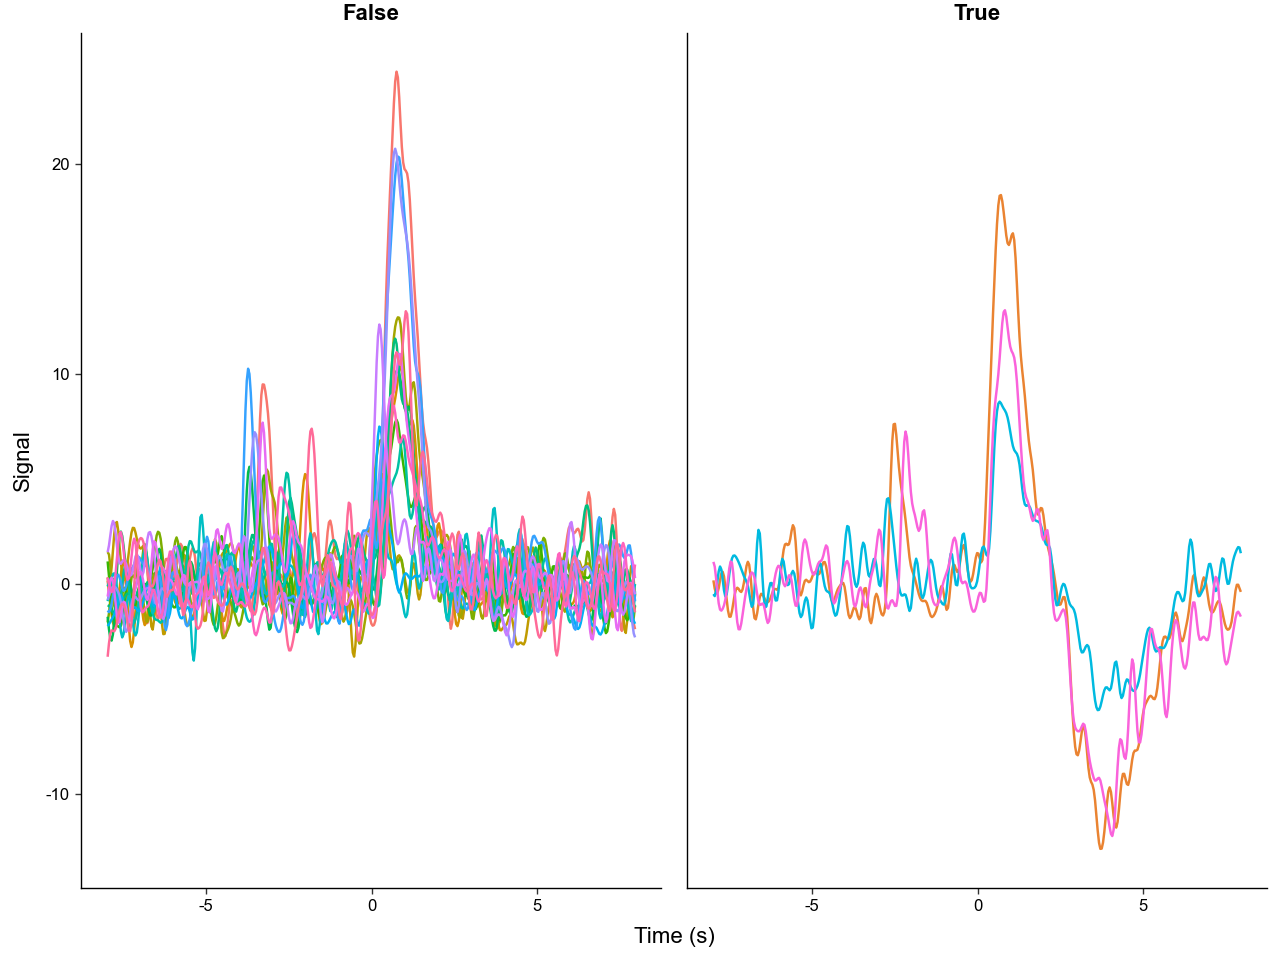

In [45]:
p = (
    trials
    .mutate_obs(
        has_shock = lambda d: ~d.obs['shock'].isna(),
    )
    .plot_trials(
        group_on='has_shock',
        downsample=4,
    )
)

p.show()

If ``baseline_bounds`` is supplied, the baseline windows are stored separately as ``baseline_data``.

In [35]:
trial_exp.baseline_data

Photometry dataset with 20 trials, 400 timepoints, and 4 observations.

# 10. Alignment and Centering Semantics

``align_to`` defines which candidate timestamps become trials. ``center_on`` decides where time zero should be in each extracted trial.

If no selected ``center_on`` event is present for a trial, that trial remains centered on its ``align_to`` timestamp.

In [36]:
cue_centered = load_processed()
cue_centered.extract_trial_data(
    align_to='trial_cue',
    center_on=None,
    trial_bounds=(-4, 6),
    trial_normalization='none',
)

cue_centered.trial_data.obs.head()

,trial_num,trial_cue,lever1,lever2,shock
0,1,0.0,3.52,NaN,NaN
1,2,0.0,2.71,NaN,3.93
2,3,0.0,NaN,NaN,NaN
3,4,0.0,3.94,NaN,NaN
4,5,0.0,3.79,NaN,NaN


``align_to`` can also receive multiple labels. In that case, all timestamps are pooled and an ``align_event`` column records which event created each trial.

In [37]:
choice_aligned = load_processed()
choice_aligned.extract_trial_data(
    align_to=['lever1', 'lever2'],
    center_on=None,
    trial_bounds=(-4, 4),
    event_tolerences={'shock': (-1, 2)},
    trial_normalization='none',
    invalid_window_policy='drop',
)

choice_aligned.trial_data.obs.head()

,trial_num,align_event,ALIGNMENTS,shock,trial_cue,lever1,lever2
0,1,lever1,0.0,NaN,-3.52,0.0,NaN
1,2,lever1,0.0,1.22,-2.71,0.0,NaN
2,3,lever1,0.0,NaN,-3.94,0.0,NaN
3,4,lever1,0.0,NaN,-3.79,0.0,NaN
4,5,lever2,0.0,NaN,-3.56,NaN,0.0


Numeric timestamps are accepted too, which is useful for manually defined windows or external event tables.

In [38]:
manual_aligned = load_processed()
manual_aligned.extract_trial_data(
    align_to=[100.0, 200.0, 300.0],
    center_on=None,
    trial_bounds=(-2, 2),
    trial_normalization='none',
)

manual_aligned.trial_data.obs.head()

,trial_num,ALIGNMENTS,trial_cue,lever1,lever2,shock
0,1,0.0,NaN,NaN,NaN,NaN
1,2,0.0,NaN,NaN,NaN,NaN
2,3,0.0,NaN,NaN,NaN,NaN


# 11. Window Alignment: Nearest vs Interp

``window_alignment='nearest'`` rounds each requested window to sampled timepoints. ``window_alignment='interp'`` interpolates the signal onto an exact centered grid. Both return fixed-size trial matrices, but the time grids can differ slightly.

In [39]:
nearest_exp = load_processed()
nearest_exp.extract_trial_data(
    align_to='trial_cue',
    center_on='lever1',
    trial_bounds=(-2, 4),
    trial_normalization='none',
    window_alignment='nearest',
)

interp_exp = load_processed()
interp_exp.extract_trial_data(
    align_to='trial_cue',
    center_on='lever1',
    trial_bounds=(-2, 4),
    trial_normalization='none',
    window_alignment='interp',
)

print(nearest_exp.trial_data.ts[:5])
print(interp_exp.trial_data.ts[:5])

[-2.00198   -1.9919701 -1.9819602 -1.9719503 -1.9619404]
[-2.        -1.9899901 -1.9799802 -1.9699703 -1.9599604]


# 12. Invalid Windows

A trial window is invalid if the requested trial or baseline interval extends outside the continuous recording. ``invalid_window_policy='error'`` makes this explicit. ``'drop'`` removes those trials and records their indexes in ``metadata['invalid_windows']``.

In [40]:
edge_case = load_processed()

try:
    edge_case.extract_trial_data(
        align_to=[1.0, 100.0],
        center_on=None,
        trial_bounds=(-8, 8),
        trial_normalization='none',
        invalid_window_policy='error',
    )
except ValueError as err:
    print(err)

Invalid trial windows that extend outside signal range at trial indicies [0]


In [41]:
drop_case = load_processed()
drop_case.extract_trial_data(
    align_to=[1.0, 100.0],
    center_on=None,
    trial_bounds=(-8, 8),
    trial_normalization='none',
    invalid_window_policy='drop',
)

print(drop_case.metadata['invalid_windows'])
print(drop_case.trial_data)

[0]
Photometry dataset with 1 trials, 1598 timepoints, and 6 observations.


# 13. Trial-wise Normalization

Baseline-dependent normalizations require ``baseline_bounds``. Built-in trial normalizations are:

* ``'none'``: leave trial windows unchanged.

* ``'zero'``: subtract the baseline center.

* ``'zscore'``: center and scale by baseline standard deviation.

* ``'mad'``: robustly scale by baseline median absolute deviation.

* ``'amp'``: scale by baseline amplitude.

Custom normalization functions receive ``trial_signals`` and ``baseline_signals`` and must return an array with the same shape as ``trial_signals``.

In [42]:
zero_exp = load_processed()
zero_exp.extract_trial_data(
    align_to='trial_cue',
    center_on=['lever1', 'lever2'],
    trial_bounds=(-4, 6),
    baseline_bounds=(-5, -1),
    trial_normalization='zero',
)

zero_exp.trial_data.X[:2, :5]

array([[ 0.00100905,  0.00110934,  0.00116969,  0.00119354,  0.00118551],
       [-0.00110786, -0.00156719, -0.00207551, -0.00262098, -0.00318975]])

In [43]:
def baseline_percent_change(trial_signals: np.ndarray, baseline_signals: np.ndarray) -> np.ndarray:
    baseline_mean = np.nanmean(baseline_signals, axis=1, keepdims=True)
    return 100 * (trial_signals - baseline_mean) / np.maximum(np.abs(baseline_mean), np.finfo(np.float32).eps)

custom_trial_norm = load_processed()
custom_trial_norm.extract_trial_data(
    align_to='trial_cue',
    center_on=['lever1', 'lever2'],
    trial_bounds=(-4, 6),
    baseline_bounds=(-5, -1),
    trial_normalization=baseline_percent_change,
)

custom_trial_norm.trial_data.X[:2, :5]

array([[  85.40988489,   93.89877845,   99.0073351 ,  101.02558605,
         100.34588329],
       [-139.11207664, -196.79009337, -260.61829873, -329.11204596,
        -400.53176948]])

# 14. Saving Extracted Trial Data

Once trial data have been extracted, ``trial_data`` is a ``PhotometryData`` object and can be saved as ``.h5ad`` or zarr.

In [44]:
trial_exp.trial_data.write_h5ad('output/signal_processing_trials.h5ad')

loaded_trials = PhotometryData.read_h5ad('output/signal_processing_trials.h5ad')
loaded_trials

Photometry dataset with 20 trials, 1598 timepoints, and 5 observations.

# Summary

``PhotometryExperiment`` is the bridge between raw continuous recordings and trial-wise analysis. It keeps raw traces, event timestamps, metadata, filtered traces, fitted references, processed signals, artifact results, and extracted trial data on one object.

The most common pattern is:

1. Load an experiment with ``load_CSV``, ``load_TDT``, or a loader class.

2. Inspect raw traces and event labels with ``plot_dashboard`` and the dataframe export methods.

3. Run ``preprocess_signal`` with settings appropriate for dual-channel or single-channel data.

4. Use ``extract_trial_data`` to build a ``PhotometryData`` object aligned to behaviorally meaningful events.

5. Save the processed continuous data or extracted trial data for later analysis.

# AI Use Disclaimer

Generative AI was used to assist in the creation of this tutorial. I plan to replace it in the future with a more polished version.